# 04 — Jira Effort Estimation: Data Understanding (EDA)

**Pregunta de negocio:** ¿cómo automatizamos la estimación de story points a partir del texto de los issues, para reducir la subestimación sistemática que rompe la planificación de sprints?

**Nota sobre el dataset:** el dataset originalmente propuesto para este proyecto (Public Jira Dataset, Zenodo) pesa **13.8 TB** y requiere login — inviable para un proyecto de portafolio. Se usa en su lugar el dataset académico que dio origen a esa línea de investigación (Choetkiertikul et al., *"A Deep Learning Model for Estimating Story Points"*, IEEE TSE 2018): **23.313 issues reales de 16 proyectos open-source** (Apache Mesos, Spring XD, Moodle, Jira Software, Titanium, etc.), con `issuekey`, `title`, `description` y `storypoint` — el mismo problema de negocio, a una escala manejable.

Este notebook cubre la fase **Data Understanding**: nulos, outliers, cardinalidad y — el hallazgo más importante de este dataset en particular — **si "story points" significa lo mismo en los 16 proyectos**.

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

DATA_DIR = '../data'

## 1. Carga y combinación de los 16 proyectos

In [2]:
files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f'{len(files)} archivos encontrados')

dfs = []
for f in files:
    project_name = os.path.splitext(os.path.basename(f))[0]
    d = pd.read_csv(f)
    d['project'] = project_name
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)
df.head(3)

16 archivos encontrados


(23313, 5)


,issuekey,title,description,storypoint,project
0,TISTUD-6,Add CA against object literals in function inv...,{html}<div><p>The idea here is that if our met...,1,appceleratorstudio
1,TISTUD-9,Update branding for Appcelerator plugin to App...,"{html}<div><p>At least fix feature icons, asso...",1,appceleratorstudio
2,TISTUD-11,Create new JSON schema for SDK team,{html}<div><p>Create JSON schema containing pr...,1,appceleratorstudio


## 2. Estructura y tipos

In [3]:
df.dtypes

issuekey         str
title            str
description      str
storypoint     int64
project          str
dtype: object

## 3. Nulos

In [4]:
print(df.isnull().sum())
print()
print('% de nulos en description por proyecto:')
print((df.groupby('project')['description'].apply(lambda s: s.isnull().mean()) * 100).round(1).sort_values(ascending=False))

issuekey          0
title             0
description    2231
storypoint        0
project           0
dtype: int64

% de nulos en description por proyecto:
project
usergrid              30.9
bamboo                28.2
jirasoftware          18.8
talenddataquality     17.7
datamanagement        13.6
springxd              13.3
talendesb             10.7
duracloud              8.0
mesos                  7.0
aptanastudio           7.0
clover                 6.0
titanium               5.7
appceleratorstudio     1.5
mulestudio             0.0
moodle                 0.0
mule                   0.0
Name: description, dtype: float64


`description` tiene 9.6% de nulos en el total, pero muy desparejo por proyecto (31% en `usergrid`, 28% en `bamboo`, vs. 0% en varios otros). **Decisión para Data Preparation:** tratar `description` nula como texto vacío (el título sigue disponible) en vez de eliminar filas — perder 31% de un proyecto sesgaría el dataset.

## 4. Duplicados

In [5]:
print('issuekey duplicados:', df['issuekey'].duplicated().sum())
print('filas duplicadas exactas:', df.duplicated().sum())

issuekey duplicados: 0
filas duplicadas exactas: 0


## 5. Volumen por proyecto

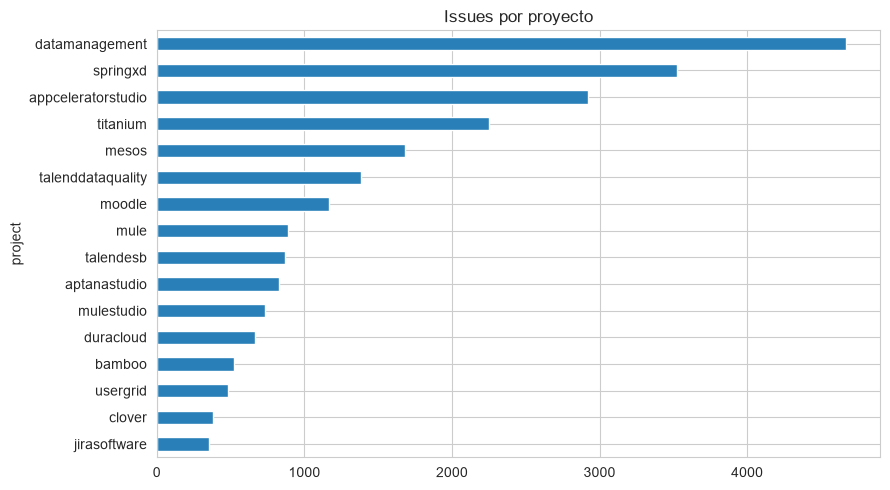

project
datamanagement        4667
springxd              3526
appceleratorstudio    2919
titanium              2251
mesos                 1680
talenddataquality     1381
moodle                1166
mule                   889
talendesb              868
aptanastudio           829
mulestudio             732
duracloud              666
bamboo                 521
usergrid               482
clover                 384
jirasoftware           352
Name: count, dtype: int64


In [6]:
counts = df['project'].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
counts.sort_values().plot(kind='barh', ax=ax, color='#2980b9')
ax.set_title('Issues por proyecto')
plt.tight_layout()
plt.show()

print(counts)

Volumen muy desparejo: `datamanagement` (4.667 issues) tiene casi 15x más que `jirasoftware` (352). Cualquier modelo entrenado sobre el pool completo va a estar dominado por los proyectos grandes.

## 6. Variable objetivo: `storypoint`

count    23313.000000
mean         6.216746
std         10.008194
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max        100.000000
Name: storypoint, dtype: float64


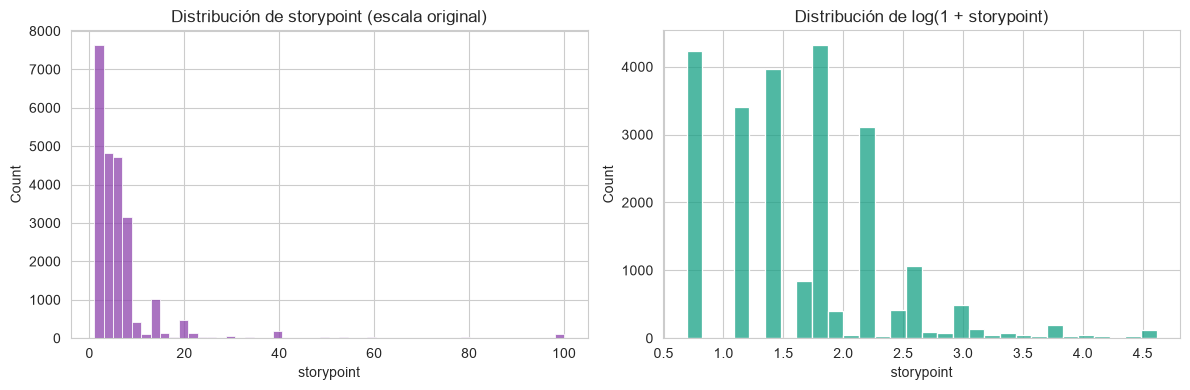

In [7]:
print(df['storypoint'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['storypoint'], bins=50, ax=axes[0], color='#8e44ad')
axes[0].set_title('Distribución de storypoint (escala original)')

sns.histplot(np.log1p(df['storypoint']), bins=30, ax=axes[1], color='#16a085')
axes[1].set_title('Distribución de log(1 + storypoint)')
plt.tight_layout()
plt.show()

Media (6.2) muy por encima de la mediana (4) y desviación estándar (10.0) mayor que la media — distribución extremadamente sesgada a la derecha, típica de story points. `log1p` la normaliza razonablemente — candidato claro para transformar el target en Data Preparation en vez de regresionar sobre la escala original.

## 7. Hallazgo crítico: los 16 proyectos NO usan la misma escala de story points

In [8]:
scale_summary = df.groupby('project')['storypoint'].agg(
    n_valores_unicos='nunique', minimo='min', maximo='max', mediana='median',
).sort_values('n_valores_unicos')
scale_summary

,n_valores_unicos,minimo,maximo,mediana
project,,,,
usergrid,5,1,8,3.0
talendesb,7,1,13,2.0
jirasoftware,8,1,20,3.0
mule,8,1,21,5.0
bamboo,9,1,20,2.0
clover,9,1,40,2.0
mulestudio,10,1,34,5.0
mesos,10,1,40,3.0
appceleratorstudio,11,1,40,5.0


C:\Users\migue\AppData\Local\Temp\ipykernel_15472\3269156562.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


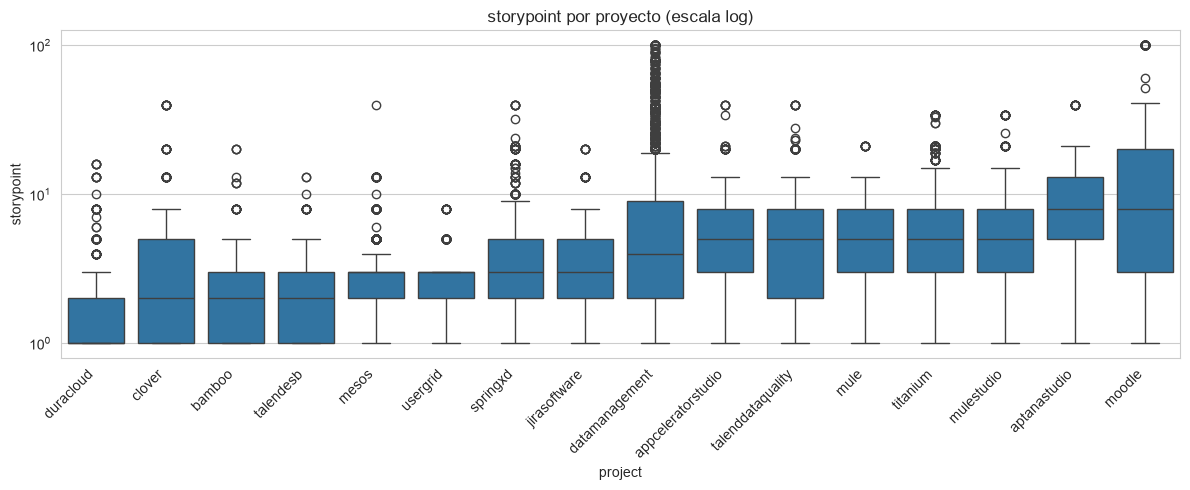

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
order = df.groupby('project')['storypoint'].median().sort_values().index
sns.boxplot(data=df, x='project', y='storypoint', order=order, ax=ax)
ax.set_yscale('log')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('storypoint por proyecto (escala log)')
plt.tight_layout()
plt.show()

**Esto es el hallazgo más importante del EDA.** `usergrid` usa estrictamente la escala Fibonacci corta `{1, 2, 3, 5, 8}` (5 valores posibles). `datamanagement` tiene **79 valores distintos** — una escala casi continua, muy distinta de "story points" en el sentido de planning poker tradicional (probablemente más cercana a horas o a una convención propia del equipo). Esto significa que **un "8" en `usergrid` y un "8" en `datamanagement` no son necesariamente comparables** — son dos escalas de medición distintas que comparten nombre de columna.

**Implicancia directa para Data Preparation y Modeling:** entrenar un único regresor sobre el pool de 16 proyectos, tratando `storypoint` como una escala universal, es metodológicamente cuestionable. Alternativas a evaluar en el próximo notebook: (a) incluir `project` como feature categórica para que el modelo aprenda un offset por proyecto, (b) normalizar `storypoint` dentro de cada proyecto (ej. z-score o rank por proyecto) antes de modelar, o (c) evaluar el modelo por proyecto además de en el pool agregado, para no esconder un mal ajuste en proyectos pequeños detrás del promedio general.

## 8. Outliers: issues de 40+ story points

In [10]:
extreme = df[df['storypoint'] >= 40]
print(f'{len(extreme)} issues ({len(extreme) / len(df):.1%}) con storypoint >= 40')
print()
print(extreme.groupby('project').size().sort_values(ascending=False))
print()
extreme[['project', 'issuekey', 'title', 'storypoint']].head(5)

478 issues (2.1%) con storypoint >= 40

project
datamanagement        282
moodle                162
aptanastudio           10
clover                  8
talenddataquality       6
springxd                5
appceleratorstudio      4
mesos                   1
dtype: int64



,project,issuekey,title,storypoint
154,appceleratorstudio,TISTUD-746,Add GIT configuration to the Dashboard,40
196,appceleratorstudio,TISTUD-952,Force installation of Android NDK if user is d...,40
199,appceleratorstudio,TISTUD-957,Implement Snippet Popup Preview,40
583,appceleratorstudio,TISTUD-1827,"Detect if node.js is installed, if not, run in...",40
2927,aptanastudio,APSTUD-769,PHP Debugger,40


~2% de los issues tienen 40+ puntos — plausiblemente "epics" mal descompuestos o placeholders de "esto es demasiado grande para estimar con precisión", más que trabajo real medido con la misma vara que un issue de 1-2 puntos. No se eliminan en esta fase (podrían ser una señal real: issues con descripción larga y compleja), pero se marcan para revisar su tratamiento (¿capar?, ¿modelar aparte?) en `02_data_preparation.ipynb`.

## 9. Texto: longitud de título y descripción

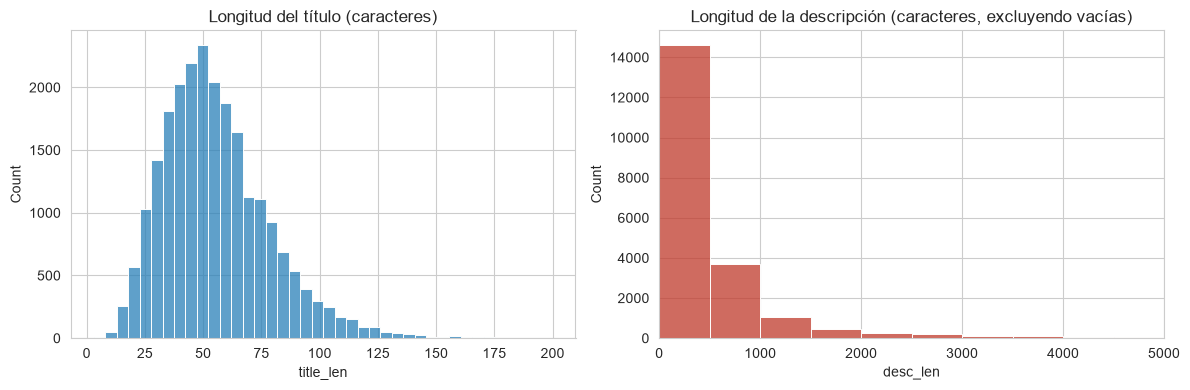

          title_len      desc_len
count  23313.000000  23313.000000
mean      55.619140    670.158109
std       23.038257   1797.691124
min        3.000000      0.000000
25%       39.000000    124.000000
50%       52.000000    270.000000
75%       68.000000    548.000000
max      200.000000  20003.000000


In [11]:
df['title_len'] = df['title'].str.len()
df['desc_len'] = df['description'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['title_len'], bins=40, ax=axes[0], color='#2980b9')
axes[0].set_title('Longitud del título (caracteres)')
sns.histplot(df[df['desc_len'] > 0]['desc_len'], bins=40, ax=axes[1], color='#c0392b')
axes[1].set_xlim(0, 5000)
axes[1].set_title('Longitud de la descripción (caracteres, excluyendo vacías)')
plt.tight_layout()
plt.show()

print(df[['title_len', 'desc_len']].describe())

## 10. Chequeo de leakage textual

¿El propio texto menciona explícitamente el story point (ej. "story point: 8"), lo cual sería trivialmente predictivo y no generalizaría a issues nuevos sin estimar todavía?

In [12]:
def mentions_points(row):
    text = (str(row['title']) + ' ' + str(row['description'])).lower()
    return any(p in text for p in ['story point', 'storypoint', 'sp:', 'points:'])

mentions = df.apply(mentions_points, axis=1)
print(f'{mentions.sum()} filas ({mentions.mean():.2%}) mencionan "story point"/"SP"/"points" en el texto')
df[mentions][['project', 'title']].head(5)

49 filas (0.21%) mencionan "story point"/"SP"/"points" en el texto


,project,title
3756,bamboo,Implement SAL part 1
4278,clover,Clover-for-Grails generates an exception when ...
4657,datamanagement,Add derivatives-based optimizer to meas_multifit
4730,datamanagement,Jira for Qserv
4832,datamanagement,rearchitect Qserv to fix dependencies between ...


Solo 0.21% — y varios son falsos positivos ("endpoints" contiene "points"). No hay evidencia de leakage textual sistemático.

## 11. Conclusiones de la fase de Data Understanding

1. **Dataset sustituto justificado:** el Zenodo original (13.8 TB, login) es inviable; se usa el dataset académico de 23.313 issues / 16 proyectos que originó esa línea de investigación — mismo problema de negocio, escala manejable.
2. **Nulos en `description`** (9.6% global, hasta 31% en `usergrid`) — se completan como texto vacío, no se eliminan filas.
3. **Sin duplicados.**
4. **Hallazgo crítico: las escalas de story points NO son comparables entre proyectos** — de 5 valores posibles (`usergrid`) a 79 (`datamanagement`). Pooling ingenuo de los 16 proyectos como una sola escala numérica es metodológicamente cuestionable; se evaluará incluir `project` como feature y/o normalizar por proyecto.
5. **~2% de outliers** (storypoint ≥ 40) — probablemente epics, se marcan para decidir tratamiento en la siguiente fase.
6. **Target extremadamente sesgado** — candidato claro para `log1p` antes de regresionar.
7. **Sin leakage textual detectado** — el texto no menciona el propio story point de forma sistemática.

**Siguiente paso:** `02_data_preparation.ipynb` — generar embeddings de texto, decidir el tratamiento de la heterogeneidad de escalas y de los outliers, y dejar el dataset listo para el modelo de regresión.